# 异常检测   

   
在本练习中，你将实现异常检测算法，并将其应用于检测网络中出现故障的服务器。


# 大纲 
- [1 - 包](#1)
- [2 - 异常检测](#2)
  - [2.1 问题陈述](#2.1)
  - [2.2 数据集](#2.2)
  - [2.3 高斯分布](#2.3)
    - [练习1](#ex01)
    - [练习2](#ex02)
  - [2.4 高维数据集](#2.4)


<a name="1"></a>
## 1 - 软件包
首先，让我们运行下面的代码块，导入本次作业所需的所有软件包。
- [numpy](www.numpy.org)是Python中用于处理矩阵的基础软件包。
- [matplotlib](http://matplotlib.org)是Python中用于绘制图表的著名库。
- ``utils.py``包含本次作业的辅助函数。你无需修改该文件中的代码。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

%matplotlib widget

<a name="2"></a>
## 2 - 异常检测

<a name="2.1"></a>
### 2.1 问题陈述   
   
在本练习中，你将实现一种异常检测算法，以检测服务器计算机中的异常行为。   
   
该数据集包含两个特征 - 
   * 吞吐量（兆字节/秒）以及
   * 每台服务器响应的延迟（毫秒）。
   
在服务器运行时，你收集了$m = 307$个关于它们运行情况的示例，因此拥有一个未标记的数据集$\{x^{(1)}, \ldots, x^{(m)}\}$。 
* 你怀疑这些示例中的绝大多数是服务器正常运行的 “正常”（非异常）示例，但在此数据集中也可能存在一些服务器异常运行的示例。
   
你将使用高斯模型来检测数据集中的异常示例。    
* 你将首先从一个二维数据集入手，这将使你能够直观地看到算法的运行过程。
* 在该数据集上，你将拟合一个高斯分布，然后找出概率极低的值，这些值因此可被视为异常值。 
* 之后，你将把异常检测算法应用于一个维度更多的更大数据集。 

<a name="2.2"></a>
### 2.2 数据集
你将从加载此任务的数据集开始。
- 如下所示的`load_data()`函数会将数据加载到变量`X_train`、`X_val`和`y_val`中
    - 你将使用`X_train`拟合高斯分布
    - 你将使用`X_val`和`y_val`作为交叉验证集来选择阈值，并确定异常示例与正常示例

In [2]:
# Load the dataset
X_train, X_val, y_val = load_data()
print(f"X_train.shape={X_train.shape},X_val.shape={X_val.shape},y_val.shape={y_val.shape}")

X_train.shape=(307, 2),X_val.shape=(307, 2),y_val.shape=(307,)


#### 查看变量
让我们更熟悉一下你的数据集。   
- 一个好的开始方式是打印出每个变量，看看它包含什么内容。
   
下面的代码会打印出每个变量的前五个元素。

In [3]:
# Display the first five elements of X_train
print("The first 5 elements of X_train are:\n", X_train[:5])  

The first 5 elements of X_train are:
 [[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]


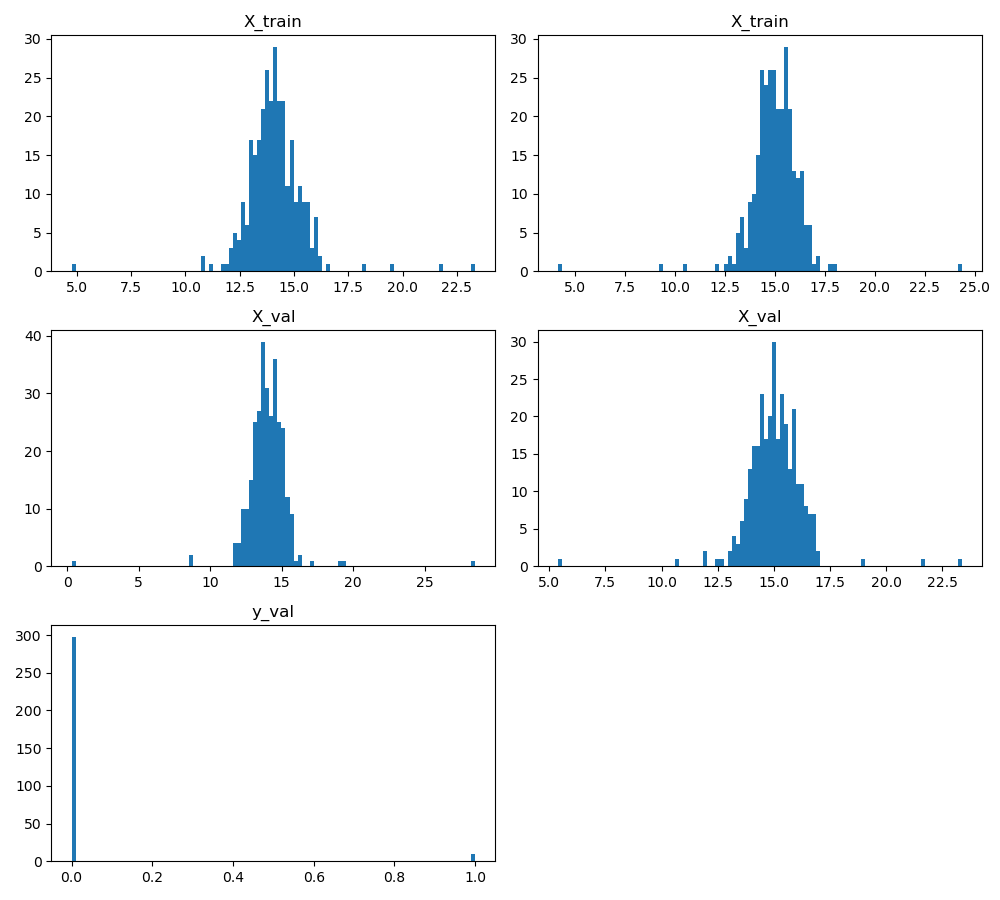

In [4]:
plt.figure(figsize=(10, 9))

plt.subplot(3,2,1)
plt.hist(X_train[:,0],bins=100)
plt.title("X_train")

plt.subplot(3,2,2)
plt.hist(X_train[:,1],bins=100)
plt.title("X_train")

plt.subplot(3,2,3)
plt.hist(X_val[:,0],bins=100)
plt.title("X_val")

plt.subplot(3,2,4)
plt.hist(X_val[:,1],bins=100)
plt.title("X_val")

plt.subplot(3,2,5)
plt.hist(y_val[:],bins=100)
plt.title("y_val")

plt.tight_layout()
plt.show()

In [5]:
# Display the first five elements of X_val
print("The first 5 elements of X_val are\n", X_val[:5])  

The first 5 elements of X_val are
 [[15.79025979 14.9210243 ]
 [13.63961877 15.32995521]
 [14.86589943 16.47386514]
 [13.58467605 13.98930611]
 [13.46404167 15.63533011]]


In [6]:
# Display the first five elements of y_val
print("The first 5 elements of y_val are\n", y_val[:5])  

The first 5 elements of y_val are
 [0 0 0 0 0]


#### 检查变量的维度
   
熟悉数据的另一种有效方法是查看其维度。   

以下代码将打印`X_train`、`X_val`和`y_val`的形状。

In [7]:
print ('The shape of X_train is:', X_train.shape)
print ('The shape of X_val is:', X_val.shape)
print ('The shape of y_val is: ', y_val.shape)

The shape of X_train is: (307, 2)
The shape of X_val is: (307, 2)
The shape of y_val is:  (307,)


#### 可视化你的数据
   
在开始任何任务之前，通过可视化数据来理解数据通常很有用。   
- 对于这个数据集，你可以使用散点图来可视化数据（`X_train`），因为它只有两个属性需要绘制（吞吐量和延迟）。
   
- 你的图表应该与下面的图表相似。


<img src="images/figure1.png" width="500" height="500">

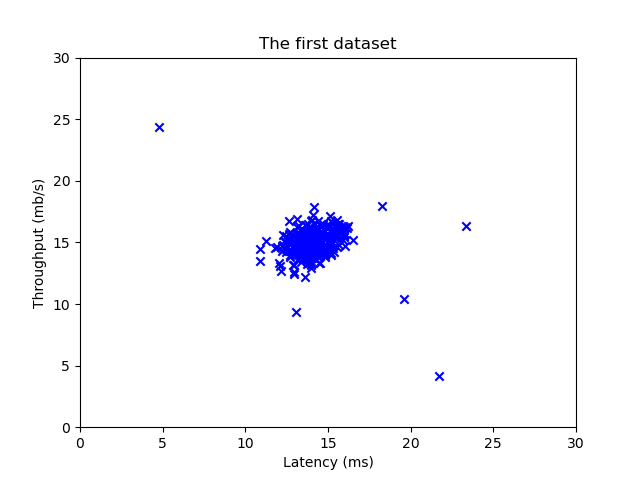

In [8]:
# Create a scatter plot of the data. To change the markers to blue "x",
# we used the 'marker' and 'c' parameters
plt.figure()

plt.scatter(X_train[:, 0], X_train[:, 1], marker='x', c='b') 

# Set the title
plt.title("The first dataset")
# Set the y-axis label
plt.ylabel('Throughput (mb/s)')
# Set the x-axis label
plt.xlabel('Latency (ms)')
# Set axis range
plt.axis([0, 30, 0, 30])
plt.show()

<a name="2.3"></a>
### 2.3 高斯分布   

要进行异常检测，首先需要对数据的分布拟合一个模型。   

* 给定一个训练集$\{x^{(1)}, ..., x^{(m)}\}$，你需要估计每个特征$x_i$的高斯分布。

* 回想一下，高斯分布由下式给出

   $$ p(x ; \mu,\sigma ^2) = \frac{1}{\sqrt{2 \pi \sigma ^2}}\exp^{ - \frac{(x - \mu)^2}{2 \sigma ^2} }$$

   其中 $\mu$ 是算数平均数，而 $\sigma^2$ 是方差.

* 对于每个特征$i = 1\ldots n$，你需要找到适合第$i$维数据$\{x_i^{(1)}, ..., x_i^{(m)}\}$ （每个示例的第$i$维）的参数$\mu_i$和$\sigma_i^2$。

### 2.2.1 估计高斯分布的参数   

**实现方法**：   

你的任务是完成下面`estimate_gaussian`中的代码。

<a name="ex01"></a>
### 练习1   

请完成下面的`estimate_gaussian`函数，以计算$\mu$（`X`中每个特征的均值）和$\sigma$（`X`中每个特征的方差）。   
   
你可以使用以下公式估计第$i$个特征的参数（$\mu_i$，$\sigma_i^2$）。要估计均值，你将使用：

$$\mu_i = \frac{1}{m} \sum_{j=1}^m x_i^{(j)}$$

而对于方差，你将使用：
$$\sigma_i^2 = \frac{1}{m} \sum_{j=1}^m (x_i^{(j)} - \mu_i)^2$$

如果你遇到困难，可以查看下面单元格之后给出的提示，以帮助你完成实现。

In [9]:
# UNQ_C1
# GRADED FUNCTION: estimate_gaussian

def estimate_gaussian(X): 
    """
    Calculates mean and variance of all features 
    in the dataset
    
    Args:
        X (ndarray): (m, n) Data matrix
    
    Returns:
        mu (ndarray): (n,) Mean of all features
        var (ndarray): (n,) Variance of all features
    """

    m, n = X.shape
    
    ### START CODE HERE ### 
    mu = 1 / m * np.sum(X, axis = 0)
    var = 1 / m * np.sum((X - mu) ** 2, axis = 0)
    ### END CODE HERE ### 
        
    return mu, var

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
  
   * You can implement this function in two ways: 
      * 1 - by having two nested for loops - one looping over the **columns** of `X` (each feature) and then looping over each data point. 
      * 2 - in a vectorized manner by using `np.sum()` with `axis = 0` parameter (since we want the sum for each column)

    
   * Here's how you can structure the overall implementation of this function for the vectorized implementation:


```python  
    def estimate_gaussian(X): 
        m, n = X.shape
    
        ### START CODE HERE ### 
        mu = # Your code here to calculate the mean of every feature
        var = # Your code here to calculate the variance of every feature 
        ### END CODE HERE ### 
        
        return mu, var
```

If you're still stuck, you can check the hints presented below to figure out how to calculate $\mu$ and $\sigma$.
    
<details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate mu</b></font></summary>
           &emsp; &emsp; You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.sum.html">np.sum</a> to with `axis = 0` parameter to get the sum for each column of an array
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate mu</b></font></summary>
               &emsp; &emsp; You can compute mu as <code>mu = 1 / m * np.sum(X, axis = 0)</code>
           </details>
    </details>
    
<details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate var</b></font></summary>
           &emsp; &emsp; You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.sum.html">np.sum</a> to with `axis = 0` parameter to get the sum for each column of an array and <code>**2</code> to get the square.
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate var</b></font></summary>
               &emsp; &emsp; You can compute var as <code> var = 1 / m * np.sum((X - mu) ** 2, axis = 0)</code>
           </details>
    </details>
    
</details>

你可以通过运行以下测试代码来检查你的实现是否正确：

In [10]:
# Estimate mean and variance of each feature
mu, var = estimate_gaussian(X_train)              

print("Mean of each feature:", mu)
print("Variance of each feature:", var)
    
# UNIT TEST
from public_tests import *
estimate_gaussian_test(estimate_gaussian)

Mean of each feature: [14.11222578 14.99771051]
Variance of each feature: [1.83263141 1.70974533]
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>Mean of each feature: <b>  </td> 
    <td> [14.11222578 14.99771051]</td> 
   </tr>    
   <tr>
    <td> <b>Variance of each feature: <b>  </td>
     <td> [1.83263141 1.70974533] </td> 
  </tr>
</table>

既然你已经完成了`estimate_gaussian`中的代码，我们将可视化拟合的高斯分布的等高线。   

你应该会得到一个与下图类似的图。 
<img src="images/figure2.png" width="500" height="500">


从你的图中可以看到，大多数示例都位于概率最高的区域，而异常示例则位于概率较低的区域。

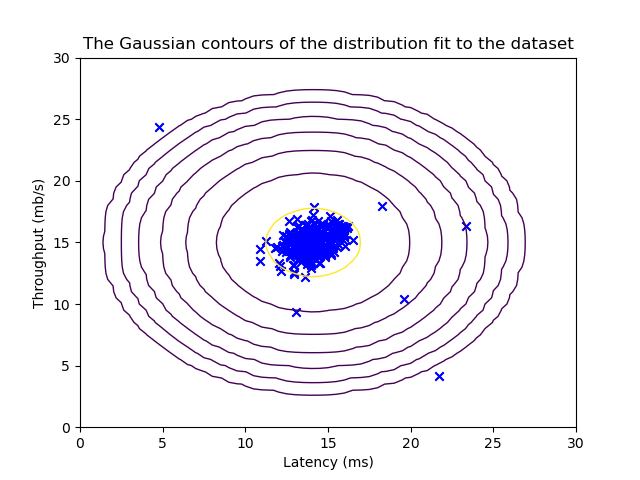

In [11]:
# Returns the density of the multivariate normal
# at each data point (row) of X_train
p = multivariate_gaussian(X_train, mu, var)

#Plotting code 
visualize_fit(X_train, mu, var)

### 2.2.2 选择阈值 $\epsilon$
既然你已经估计出了高斯参数，就可以研究在这个分布下，哪些样本具有很高的概率，哪些样本具有很低的概率。   

* 概率低的样本更有可能是数据集中的异常值。
* 确定哪些样本是异常值的一种方法是基于交叉验证集选择一个阈值。
   
在本节中，你将完成 `select_threshold` 中的代码，使用交叉验证集上的 $F_1$ 分数来选择阈值 $\varepsilon$。   

* 为此，我们将使用一个交叉验证集
$\{(x_{\rm cv}^{(1)}, y_{\rm cv}^{(1)}),\ldots, (x_{\rm cv}^{(m_{\rm cv})}, y_{\rm cv}^{(m_{\rm cv})})\}$，其中标签 $y = 1$ 对应异常样本，$y = 0$ 对应正常样本。
* 对于每个交叉验证样本，我们将计算 $p(x_{\rm cv}^{(i)})$。所有这些概率组成的向量 $p(x_{\rm cv}^{(1)}), \ldots, p(x_{\rm cv}^{(m_{\rm cv})})$ 会以向量 `p_val` 的形式传递给 `select_threshold`。
* 相应的标签 $y_{\rm cv}^{(1)}, \ldots, y_{\rm cv}^{(m_{\rm cv})}$ 会以向量 `y_val` 的形式传递给同一个函数。

<a name="ex02"></a>
### 练习2
请完成下面的`select_threshold`函数，根据验证集（`p_val`）的结果和真实情况（`y_val`），找出用于选择异常值的最佳阈值。   

* 在提供的代码`select_threshold`中，已经有一个循环，它会尝试许多不同的$\varepsilon$值，并根据$F_1$分数选择最佳的$\varepsilon$。

* 你需要实现代码，计算选择`epsilon`作为阈值时的F1分数，并将该值放入`F1`中。
   
  * 请记住，如果一个样本$x$的概率$p(x)$较低，即$p(x) < \varepsilon$，那么它会被归类为异常值。

  * 然后，你可以通过以下公式计算精确率和召回率：   
   $$\begin{aligned}
   精确率&=&\frac{真正例}{真正例+假正例}\\
   召回率&=&\frac{真正例}{真正例+假反例},
   \end{aligned}$$ 其中
    * $tp$（真正例）是真实标签表明它是异常值，并且我们的算法正确地将其归类为异常值的数量。
    * $fp$（假正例）是真实标签表明它不是异常值，但我们的算法错误地将其归类为异常值的数量。
    * $fn$（假反例）是真实标签表明它是异常值，但我们的算法错误地将其归类为非异常值的数量。

  * $F_1$分数使用精确率（$prec$）和召回率（$rec$）按如下方式计算：
    $$F_1 = \frac{2\cdot 精确率 \cdot 召回率}{精确率 + 召回率}$$
 

**实现注意事项：** 
为了计算$tp$、$fp$和$fn$，你或许可以使用向量化实现，而不是对所有样本进行循环。   

如果你遇到困难，可以查看下面单元格之后给出的提示，以帮助你完成实现。

In [14]:
# UNQ_C2
# GRADED FUNCTION: select_threshold

def select_threshold(y_val, p_val): 
    """
    Finds the best threshold to use for selecting outliers 
    based on the results from a validation set (p_val) 
    and the ground truth (y_val)
    
    Args:
        y_val (ndarray): Ground truth on validation set
        p_val (ndarray): Results on validation set
        
    Returns:
        epsilon (float): Threshold chosen 
        F1 (float):      F1 score by choosing epsilon as threshold
    """ 

    best_epsilon = 0
    best_F1 = 0
    F1 = 0
    
    step_size = (max(p_val) - min(p_val)) / 1000
    
    for epsilon in np.arange(min(p_val), max(p_val), step_size):
    
        ### START CODE HERE ### 
        predictions = (p_val < epsilon)
        
        tp = np.sum((predictions == 1) & (y_val == 1)) #真阳性
        fp = sum((predictions == 1) & (y_val == 0))    #假阳性
        fn = np.sum((predictions == 0) & (y_val == 1)) #假阴性

        if tp + fp == 0:
            prec = 0
        else:
            prec = tp / (tp + fp)

        if tp + fn == 0:
            rec = 0
        else:
            rec = tp / (tp + fn)

        if prec + rec == 0:
            F1 = 0
        else:
            F1 = 2 * prec * rec / (prec + rec)
        ### END CODE HERE ### 
        
        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon
        
    return best_epsilon, best_F1

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>

   * Here's how you can structure the overall implementation of this function for the vectorized implementation:

```python  
    def select_threshold(y_val, p_val): 
        best_epsilon = 0
        best_F1 = 0
        F1 = 0
    
        step_size = (max(p_val) - min(p_val)) / 1000
    
        for epsilon in np.arange(min(p_val), max(p_val), step_size):
    
            ### START CODE HERE ### 
            predictions = # Your code here to calculate predictions for each example using epsilon as threshold
        
            tp = # Your code here to calculate number of true positives
            fp = # Your code here to calculate number of false positives
            fn = # Your code here to calculate number of false negatives
        
            prec = # Your code here to calculate precision
            rec = # Your code here to calculate recall
        
            F1 = # Your code here to calculate F1
            ### END CODE HERE ### 
        
            if F1 > best_F1:
                best_F1 = F1
                best_epsilon = epsilon
        
        return best_epsilon, best_F1
```

If you're still stuck, you can check the hints presented below to figure out how to calculate each variable.
    
<details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate predictions</b></font></summary>
           &emsp; &emsp; If an example  𝑥  has a low probability  $p(x) < \epsilon$ , then it is classified as an anomaly. To get predictions for each example (0/ False for normal and 1/True for anomaly), you can use <code>predictions = (p_val < epsilon)</code>
    </details>
    
<details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate tp, fp, fn</b></font></summary>
           &emsp; &emsp; 
        <ul>
          <li>If you have several binary values in an $n$-dimensional
binary vector, you can find out how many values in this vector are 0 by using:  `np.sum(v == 0)`</li>
          <li>You can also apply a logical *and* operator to such binary vectors. For instance,  `predictions` is a binary vector of the size of your number of cross validation set, where the $i$-th element is 1 if your algorithm considers $x_{\rm cv}^{(i)}$ an anomaly, and 0 otherwise. </li>
          <li>You can then, for example, compute the number of false positives using:  
<code>fp = sum((predictions == 1) & (y_val == 0))</code>.</li>
        </ul>
         <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate tp, fn</b></font></summary>
               &emsp; &emsp;
             <ul>
              <li>You can compute tp as <code> tp = np.sum((predictions == 1) & (y_val == 1))</code></li>
              <li>You can compute tn as <code> fn = np.sum((predictions == 0) & (y_val == 1))</code></li>  
              </ul>
          </details>
    </details>
        
<details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate precision</b></font></summary>
           &emsp; &emsp; You can calculate precision as <code>prec = tp / (tp + fp)</code>
    </details>
        
<details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate recall</b></font></summary>
           &emsp; &emsp; You can calculate recall as <code>rec = tp / (tp + fn)</code>
</details>
        
<details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate F1</b></font></summary>
           &emsp; &emsp; You can calculate F1 as <code>F1 = 2 * prec * rec / (prec + rec)</code>
    </details>
    
</details>

你可以使用以下代码检查你的实现

In [15]:
p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('Best epsilon found using cross-validation: %e' % epsilon)
print('Best F1 on Cross Validation Set: %f' % F1)
    
# UNIT TEST
select_threshold_test(select_threshold)


Best epsilon found using cross-validation: 8.990853e-05
Best F1 on Cross Validation Set: 0.875000
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>Best epsilon found using cross-validation: <b>  </td> 
    <td> 8.99e-05</td> 
   </tr>    
   <tr>
    <td> <b>Best F1 on Cross Validation Set: <b>  </td>
     <td> 0.875 </td> 
  </tr>
</table>

现在我们将运行你的异常检测代码，并在图中（如下方图3所示）圈出异常点。

<img src="images/figure3.png" width="500" height="500">

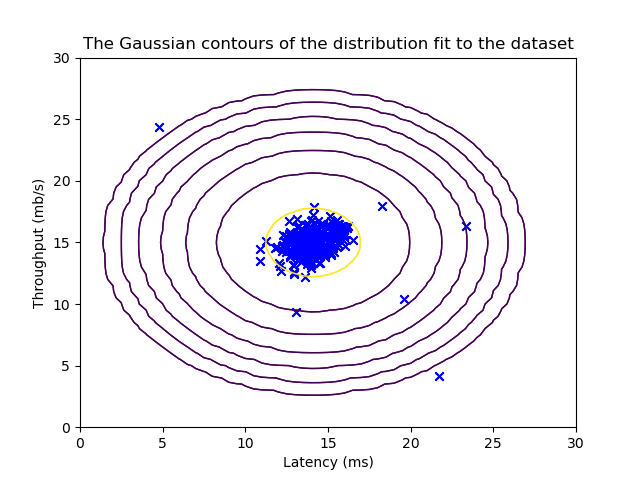

In [16]:
# Find the outliers in the training set 
outliers = p < epsilon

# Visualize the fit
visualize_fit(X_train, mu, var)

# Draw a red circle around those outliers
plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize= 10,markerfacecolor='none', markeredgewidth=2)

<a name="2.4"></a>
### 2.4 高维数据集

现在，我们将运行你所实现的异常检测算法，该算法将应用于一个更贴近实际且难度更大的数据集。   

在这个数据集中，每个样本由11个特征描述，涵盖了你的计算服务器的更多属性。   

让我们从加载数据集开始。   

- 如下所示的`load_data()`函数会将数据加载到变量`X_train_high`、`X_val_high`和`y_val_high`中
    - `_high`用于将这些变量与前一部分使用的变量区分开来
    - 我们将使用`X_train_high`来拟合高斯分布 
    - 我们将使用`X_val_high`和`y_val_high`作为交叉验证集，以选择一个阈值，并确定异常样本与正常样本

In [17]:
# load the dataset
X_train_high, X_val_high, y_val_high = load_data_multi()

#### 检查变量的维度
让我们检查这些新变量的维度，以便熟悉数据。

In [18]:
print ('The shape of X_train_high is:', X_train_high.shape)
print ('The shape of X_val_high is:', X_val_high.shape)
print ('The shape of y_val_high is: ', y_val_high.shape)

The shape of X_train_high is: (1000, 11)
The shape of X_val_high is: (100, 11)
The shape of y_val_high is:  (100,)


#### 异常检测   

现在，让我们在这个新数据集上运行异常检测算法。   

下面的代码将使用你编写的代码来：
* 估计高斯参数（$\mu_i$ 和 $\sigma_i^2$）
* 评估用于估计高斯参数的训练数据 `X_train_high` 以及交叉验证集 `X_val_high` 的概率。
* 最后，它将使用 `select_threshold` 来找到最佳阈值 $\varepsilon$。

In [19]:
# Apply the same steps to the larger dataset

# Estimate the Gaussian parameters
mu_high, var_high = estimate_gaussian(X_train_high)

# Evaluate the probabilites for the training set
p_high = multivariate_gaussian(X_train_high, mu_high, var_high)

# Evaluate the probabilites for the cross validation set
p_val_high = multivariate_gaussian(X_val_high, mu_high, var_high)

# Find the best threshold
epsilon_high, F1_high = select_threshold(y_val_high, p_val_high)

print('Best epsilon found using cross-validation: %e'% epsilon_high)
print('Best F1 on Cross Validation Set:  %f'% F1_high)
print('# Anomalies found: %d'% sum(p_high < epsilon_high))

Best epsilon found using cross-validation: 1.377229e-18
Best F1 on Cross Validation Set:  0.615385
# Anomalies found: 117


**Expected Output**:
<table>
  <tr>
    <td> <b>Best epsilon found using cross-validation: <b>  </td> 
    <td> 1.38e-18</td> 
   </tr>    
   <tr>
    <td> <b>Best F1 on Cross Validation Set: <b>  </td>
     <td> 0.615385 </td> 
  </tr>
    <tr>
    <td> <b># anomalies found: <b>  </td>
     <td>  117 </td> 
  </tr>
</table>